# Sample Similarity

[![open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ing-bank/probatus/blob/master/docs/tutorials/nb_sample_similarity.ipynb)

The goal of a Resemblance Model is understanding how different two samples are from a multivariate perspective. For instance, if you suspect that your Out-Of-Time Test set may have a different distribution than the In-Time Train set, you can detect that using the Resemblance Model.

<img src="../img/resemblance_model_schema.png" width="900">

Having two samples `X1` and `X2` with the same set of features, one can analyse how well a model can recognize which dataset a randomly selected row comes from. The Resemblance model assigns label `0` to `X1` dataset, and label `1` to `X2`. Then, the data is shuffled and split into a Train split (`X_train`, `y_train`) and a Test split (`X_test`, `y_test`).

The user provides a binary classifier that is then fitted on the Train split and evaluated on both Train and Test.
Interpreting such a model allows us to understand which features and interactions between them differ between these two samples.

It is crucial that the model does not overfit or underfit, because the interpretation of such a model will lead to the wrong conclusions. Therefore, you should try fitting the model with a couple of different hyperparameter settings, and subsequently make sure that the `Train AUC` is not significantly higher than the `Test AUC`

Once you have the final Resemblance Model, a `Test AUC` significantly above 0.5 indicates the predictive power of the model, as well as the change in the distribution between `X1` and `X2`. The higher the `Test AUC`, the larger the difference between two datasets.

You can then further inspect the model, in order to understand the patterns that the model has learned.
There are two classes in `probatus` that allow you to analyse which features have changed between two samples:

- **SHAPImportanceResemblance (Recommended)** - Trains a Resemblance model based on a **tree classifier**, then it uses SHAP library to analyse the differences in features between the two samples. The main advantage of using this method is its high speed, better understanding of the relations in the data and handling of categorical features and missing values.

- **PermutationImportanceResemblance** - Trains a Resemblance model for **any provided classifier**, and uses Permutation Importance to analyse, which features the model relies on. It is significantly slower, and requires preprocessing of the data before training the resemblance model.

## Setup

In [1]:
%%capture
!pip install probatus

In [2]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# Prepare two samples
feature_names = ["f1", "f2", "f3", "f4"]
X1 = pd.DataFrame(make_classification(n_samples=1000, n_features=4, random_state=0)[0], columns=feature_names)
X2 = pd.DataFrame(
    make_classification(n_samples=1000, n_features=4, shift=0.5, random_state=0)[0], columns=feature_names
)

# Prepare model
model = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=0)

## SHAP Importance Resemblance Model for Tree models

Below you can see an example of how to use the model:

In [3]:
from IPython.display import display

from probatus.dataset import SHAPImportanceResemblance

rm = SHAPImportanceResemblance(model)
feature_importance, train_auc, test_auc = rm.fit_compute(X1, X2, column_names=feature_names, return_scores=True)

display(feature_importance)

,mean_abs_shap_value,mean_shap_value
f1,0.068984,0.004341
f3,0.068099,0.000540
f2,0.035487,-0.003325
f4,0.025628,0.003236


By looking into the above results, one can conclude that the two samples significantly differ, since the Test AUC of the model is very high.

The table shows the mean absolute shap values and mean shap values for the model's features:

- **Mean Absolute SHAP Values** provide insights about overall **SHAP feature importance**.

- **Mean SHAP Values** show in which direction on average the feature influences the prediction. Negative value indicates 0 class, and positive indicates 1 class.

Below, the SHAP feature importance is plotted

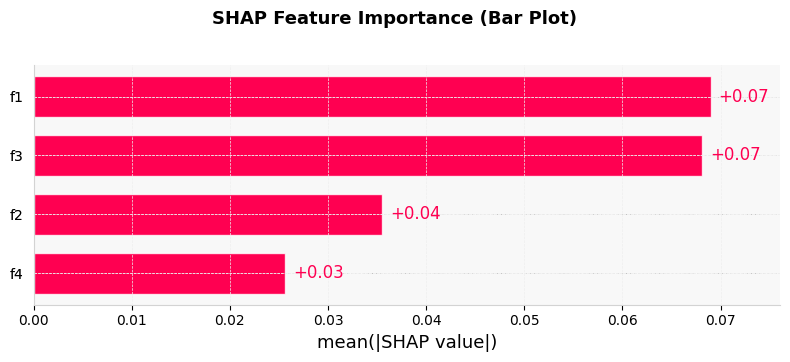

In [4]:
rm.plot()

In order to get more insights of the change in underlying relations in the data, let's plot a beeswarm plot.

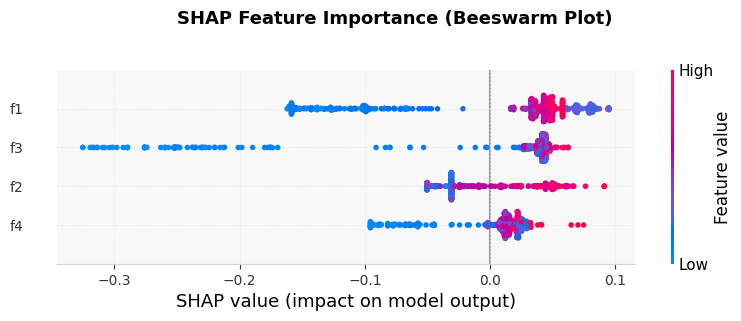

In [ ]:
rm.plot(plot="beeswarm")

Zooming in on how some samples interact with these features on an individual level can be done by plotting a Waterfall plot. You do this by providing the number of a sample in the dataset.

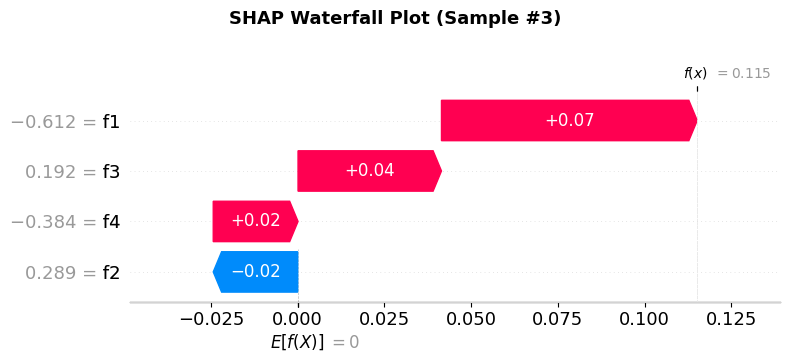

In [6]:
rm.plot(plot=3)

We can see that the second sample have higher values in all the features.

## Permutation Importance Resemblance Model

Below we show the example on how to use the PermutationImportanceResemblance

In [9]:
from probatus.dataset import PermutationImportanceResemblance

perm = PermutationImportanceResemblance(model)

feature_importance, train_auc, test_auc = perm.fit_compute(X1, X2, column_names=feature_names, return_scores=True)
display(feature_importance)

,mean_importance,std_importance
f3,0.120071,0.012479
f1,0.102917,0.018166
f2,0.026286,0.009861
f4,0.007465,0.007319


Same as before, we can get more insights into the importance of the features. However, now we can also analyse the standard deviation of the permutation importance. A high standard deviation might indicate that the permutation of this feature has a higher or lower impact only in part of the available samples, while a low standard deviation indicates a consistent effect.

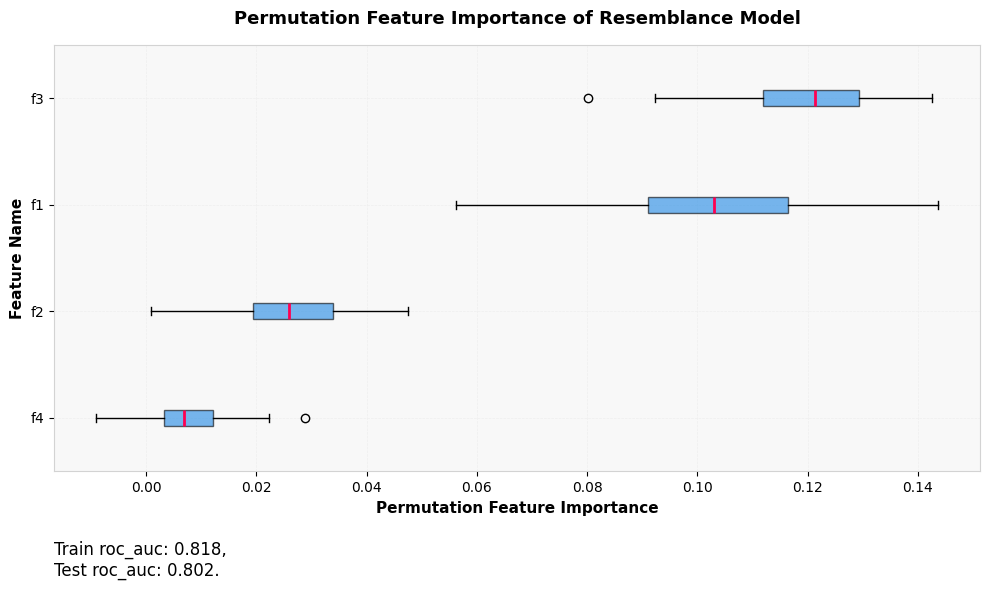

In [10]:
perm.plot()